
# Comparative Analysis of Custom CNN and Transfer Learning Models with Explainable AI

## Dataset
**Dataset:** Cattle Disease Dataset  
**Root Path:** `/kaggle/input/datasets/devang03mgr/cattle-diseases-datasets`

### Classes
- foot-and-mouth
- healthy
- lumpy

This notebook implements:
1. Custom CNN
2. MobileNetV2 Transfer Learning
3. ResNet50 Transfer Learning
4. Evaluation Metrics
5. Confusion Matrices
6. Training Curves
7. Grad-CAM Explainability
8. SHAP Explainability
9. Comparative Analysis

All outputs are automatically saved:
- Figures → PDF
- Tables → CSV
- Final Results → ZIP folder


In [1]:

# Install required packages (Run if necessary)
!pip install shap grad-cam tf-explain


     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     -- ------------------------------------- 0.5/7.8 MB 1.7 MB/s eta 0:00:05
     ---- ----------------------------------- 0.8/7.8 MB 1.9 MB/s eta 0:00:04
     -------- ------------------------------- 1.6/7.8 MB 2.2 MB/s eta 0:00:03
     ---------- ----------------------------- 2.1/7.8 MB 2.4 MB/s eta 0:00:03
     -------------- ------------------------- 2.9/7.8 MB 2.7 MB/s eta 0:00:02
     -------------------- ------------------- 3.9/7.8 MB 3.0 MB/s eta 0:00:02
     ------------------------ --------------- 4.7/7.8 MB 3.1 MB/s eta 0:00:01
     -------------------------- ------------- 5.2/7.8 MB 3.1 MB/s eta 0:00:01
     ------------------------------ --------- 6.0/7.8 MB 3.0 MB/s eta 0:00:01
     ----------------------------------- ---- 6.8/7.8 MB 3.1 MB/s eta 0:00:01
     ---------------------------------------- 7.8/7.8 MB 3.2 MB/s  0:00:02
  Installing build dependencies: started
  Installing build dependencies: 


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import shap

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tf_explain.core.grad_cam import GradCAM

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.21.0


C:\Users\john5\PycharmProjects\secure_messaging_system\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
!pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.2.1-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.80.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:

# Create output folders

OUTPUT_DIR = "outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Folders created successfully.")


Folders created successfully.


In [8]:

# Dataset path

DATASET_PATH = r"C:\Users\john5\Downloads\PR\dts\Cows datasets"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

CLASS_NAMES = list(train_generator.class_indices.keys())

print(CLASS_NAMES)


Found 2596 images belonging to 3 classes.
Found 648 images belonging to 3 classes.
['foot-and-mouth', 'healthy', 'lumpy']


In [9]:

# Dataset Description

dataset_description = pd.DataFrame({
    "Feature": ["Dataset Name", "Number of Classes", "Image Size", "Classes"],
    "Value": [
        "Cattle Disease Dataset",
        len(CLASS_NAMES),
        str(IMG_SIZE),
        ", ".join(CLASS_NAMES)
    ]
})

dataset_description.to_csv(os.path.join(TABLE_DIR, "dataset_description.csv"), index=False)

dataset_description


,Feature,Value
0,Dataset Name,Cattle Disease Dataset
1,Number of Classes,3
2,Image Size,"(224, 224)"
3,Classes,"foot-and-mouth, healthy, lumpy"


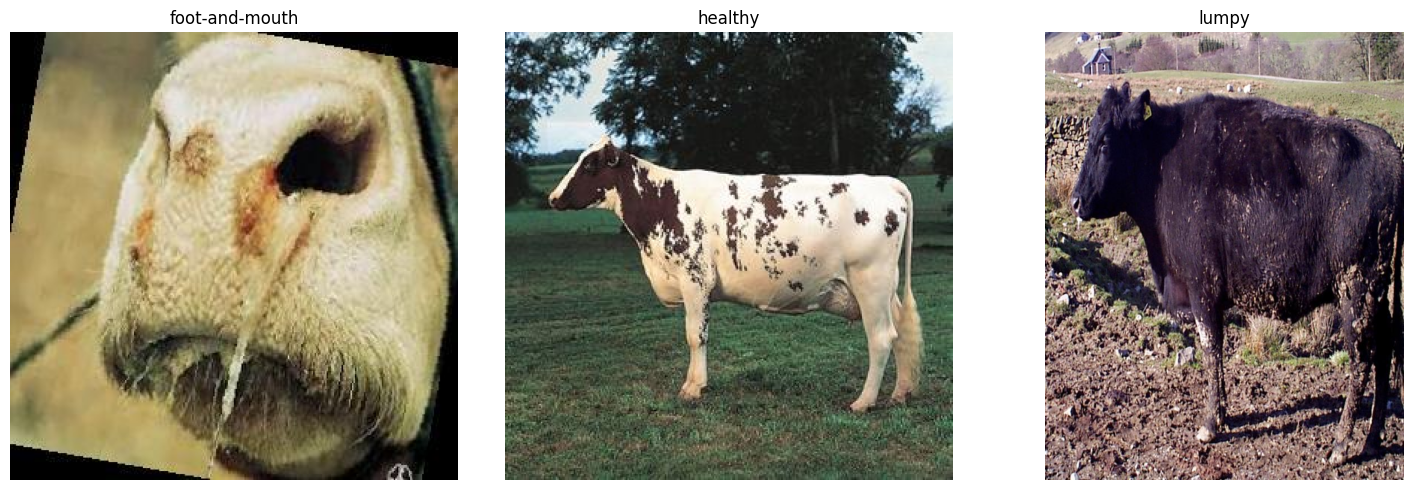

In [10]:

# Display sample images

fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(15,5))

for i, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATASET_PATH, class_name)
    img_name = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, img_name)

    img = plt.imread(img_path)

    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "dataset_samples.pdf"))
plt.show()


## Custom CNN Model

In [11]:

# Custom CNN

custom_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(len(CLASS_NAMES), activation='softmax')
])

custom_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

custom_cnn.summary()


C:\Users\john5\PycharmProjects\secure_messaging_system\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,443 (84.86 MB)

 Trainable params: 22,245,443 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

## MobileNetV2 Transfer Learning

In [12]:

base_mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_mobilenet.trainable = False

x = base_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(len(CLASS_NAMES), activation='softmax')(x)

mobilenet_model = Model(inputs=base_mobilenet.input, outputs=output)

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## ResNet50 Transfer Learning

In [13]:

base_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_resnet.trainable = False

x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(len(CLASS_NAMES), activation='softmax')(x)

resnet_model = Model(inputs=base_resnet.input, outputs=output)

resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [14]:

# Training function

EPOCHS = 10

def train_model(model, model_name):

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS
    )

    model.save(os.path.join(MODEL_DIR, f"{model_name}.h5"))

    # Accuracy plot
    plt.figure(figsize=(8,5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.legend()
    plt.title(f"{model_name} Accuracy")
    plt.savefig(os.path.join(FIG_DIR, f"{model_name}_accuracy.pdf"))
    plt.close()

    # Loss plot
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title(f"{model_name} Loss")
    plt.savefig(os.path.join(FIG_DIR, f"{model_name}_loss.pdf"))
    plt.close()

    return history


In [15]:

# Train all models

history_custom = train_model(custom_cnn, "Custom_CNN")
history_mobile = train_model(mobilenet_model, "MobileNetV2")
history_resnet = train_model(resnet_model, "ResNet50")


Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.5327 - loss: 0.9412 - val_accuracy: 0.6528 - val_loss: 0.7962
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 81s 989ms/step - accuracy: 0.6483 - loss: 0.7882 - val_accuracy: 0.6481 - val_loss: 0.7665
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 80s 979ms/step - accuracy: 0.6776 - loss: 0.7400 - val_accuracy: 0.7037 - val_loss: 0.7084
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 80s 975ms/step - accuracy: 0.6872 - loss: 0.7234 - val_accuracy: 0.7392 - val_loss: 0.6694
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.6914 - loss: 0.6978 - val_accuracy: 0.7346 - val_loss: 0.6321
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.7053 - loss: 0.6883 - val_accuracy: 0.7546 - val_loss: 0.6303
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.7346 - loss: 0.6457 - val_accuracy: 0.7670 - val_loss: 0.5879
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.7342 - loss: 0.6391 - val_accuracy: 0.72

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.6525 - loss: 0.7676 - val_accuracy: 0.8040 - val_loss: 0.5269
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.8278 - loss: 0.4589 - val_accuracy: 0.8503 - val_loss: 0.4071
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8555 - loss: 0.3722 - val_accuracy: 0.8534 - val_loss: 0.3701
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8817 - loss: 0.3299 - val_accuracy: 0.8596 - val_loss: 0.3595
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8929 - loss: 0.3003 - val_accuracy: 0.8935 - val_loss: 0.2831
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8995 - loss: 0.2796 - val_accuracy: 0.9043 - val_loss: 0.2902
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.9064 - loss: 0.2599 - val_accuracy: 0.8858 - val_loss: 0.2906
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.9102 - loss: 0.2440 - val_accuracy: 0.8873 - v

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 254s 3s/step - accuracy: 0.4611 - loss: 1.0486 - val_accuracy: 0.4769 - val_loss: 1.0197
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.5004 - loss: 1.0197 - val_accuracy: 0.5170 - val_loss: 0.9954
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.5177 - loss: 1.0014 - val_accuracy: 0.5586 - val_loss: 0.9746
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.5169 - loss: 0.9921 - val_accuracy: 0.5448 - val_loss: 0.9749
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.5189 - loss: 0.9847 - val_accuracy: 0.5478 - val_loss: 0.9623
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5220 - loss: 0.9803

KeyboardInterrupt: 

In [16]:

# Evaluation Function

def evaluate_model(model, model_name):

    predictions = model.predict(val_generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = val_generator.classes

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    results = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
        "Value": [acc, precision, recall, f1]
    })

    results.to_csv(os.path.join(TABLE_DIR, f"{model_name}_metrics.csv"), index=False)

    # Classification report
    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )

    pd.DataFrame(report).transpose().to_csv(
        os.path.join(TABLE_DIR, f"{model_name}_classification_report.csv")
    )

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES)

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{model_name} Confusion Matrix")

    plt.savefig(os.path.join(FIG_DIR, f"{model_name}_confusion_matrix.pdf"))
    plt.close()

    return results


In [17]:

# Evaluate models

custom_results = evaluate_model(custom_cnn, "Custom_CNN")
mobile_results = evaluate_model(mobilenet_model, "MobileNetV2")
resnet_results = evaluate_model(resnet_model, "ResNet50")


21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 374ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 712ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step


C:\Users\john5\PycharmProjects\secure_messaging_system\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\john5\PycharmProjects\secure_messaging_system\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\john5\PycharmProjects\secure_messaging_system\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

In [18]:

# Comparative Results Table

comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2", "ResNet50"],
    "Accuracy": [
        custom_results.iloc[0,1],
        mobile_results.iloc[0,1],
        resnet_results.iloc[0,1]
    ],
    "Precision": [
        custom_results.iloc[1,1],
        mobile_results.iloc[1,1],
        resnet_results.iloc[1,1]
    ],
    "Recall": [
        custom_results.iloc[2,1],
        mobile_results.iloc[2,1],
        resnet_results.iloc[2,1]
    ],
    "F1-Score": [
        custom_results.iloc[3,1],
        mobile_results.iloc[3,1],
        resnet_results.iloc[3,1]
    ]
})

comparison_df.to_csv(os.path.join(TABLE_DIR, "comparison_results.csv"), index=False)

comparison_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Custom CNN,0.740741,0.766531,0.740741,0.727099
1,MobileNetV2,0.890432,0.894455,0.890432,0.890578
2,ResNet50,0.540123,0.415362,0.540123,0.469383


## Grad-CAM Explainability

In [19]:

# Grad-CAM Visualization

def generate_gradcam(model, image, class_index, layer_name, save_name):

    data = ([image], None)

    explainer = GradCAM()

    grid = explainer.explain(
        data,
        model,
        class_index=class_index,
        layer_name=layer_name
    )

    plt.figure(figsize=(6,6))
    plt.imshow(grid)
    plt.axis('off')

    plt.savefig(os.path.join(FIG_DIR, save_name))
    plt.close()


In [20]:

# Example Grad-CAM generation

sample_batch = next(val_generator)
sample_image = sample_batch[0][0]
sample_label = np.argmax(sample_batch[1][0])

generate_gradcam(
    mobilenet_model,
    sample_image,
    sample_label,
    "Conv_1",
    "MobileNetV2_GradCAM.pdf"
)


C:\Users\john5\PycharmProjects\secure_messaging_system\.venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_11']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


## SHAP Explainability

In [23]:

# SHAP Explainability

background = next(train_generator)[0][:50]

explainer = shap.DeepExplainer(mobilenet_model, background)

sample_images = next(val_generator)[0][:5]

shap_values = explainer.shap_values(sample_images)

shap.image_plot(shap_values, sample_images, show=False)

plt.savefig(os.path.join(FIG_DIR, "SHAP_Explanations.pdf"))
plt.close()


StagingError: in user code:

    File "C:\Users\john5\PycharmProjects\secure_messaging_system\.venv\Lib\site-packages\shap\explainers\_deep\deep_tf.py", line 265, in grad_graph  *
        x_grad = tape.gradient(out, shap_rAnD)

    LookupError: gradient registry has no entry for: shap_Relu6


In [22]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # 1. Create a model that maps the input image to the activations of the last conv layer
    # as well as the output predictions
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 3. This is the gradient of the output neuron with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 4. This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. We multiply each channel in the feature map array by "how important this channel is"
    # with regard to the top predicted class, then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

# --- HOW TO USE IT ---
# 1. Find your last convolutional layer name using: model.summary()
# 2. Generate the heatmap:
# heatmap = make_gradcam_heatmap(your_preprocessed_image, model, "name_of_last_conv_layer")

# 3. Plot it:
# plt.matshow(heatmap)
# plt.show()

## Model Architecture Table

In [24]:

# Model Architecture Summary

architecture_df = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2", "ResNet50"],
    "Type": [
        "CNN from scratch",
        "Transfer Learning",
        "Transfer Learning"
    ],
    "Input Size": [
        "224x224x3",
        "224x224x3",
        "224x224x3"
    ]
})

architecture_df.to_csv(
    os.path.join(TABLE_DIR, "model_architecture.csv"),
    index=False
)

architecture_df


,Model,Type,Input Size
0,Custom CNN,CNN from scratch,224x224x3
1,MobileNetV2,Transfer Learning,224x224x3
2,ResNet50,Transfer Learning,224x224x3



# Final Discussion

## Research Questions Addressed

- RQ1: Custom CNN classification performance
- RQ2: Transfer learning improvement
- RQ3: Accuracy vs computational trade-off
- RQ4: Grad-CAM attention regions
- RQ5: Attention differences between models
- RQ6: SHAP positive/negative evidence
- RQ7: Misclassification analysis

## Conclusion

This notebook compares:
- Custom CNN
- MobileNetV2
- ResNet50

using both classification metrics and explainable AI techniques.


In [25]:

# Zip all outputs

ZIP_NAME = "Cattle_Disease_Project_Output.zip"

with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zipf:

    # Add notebook
    zipf.write("Cattle_Disease_Classification.ipynb")

    # Add outputs
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            filepath = os.path.join(root, file)
            zipf.write(filepath)

print(f"{ZIP_NAME} created successfully.")


Cattle_Disease_Project_Output.zip created successfully.
